# Analysis of finished ```.npz``` files

This Jupyter-Notebook should load the ```.npz```-files which contain the background-residual-field without any coil current, the field with coil current and the simulation results for the field with coil current. *Note* that ```.npz``` files (numpy-zip) need to be within the specified directory. This Code is not supposed to by tidy, but include everything necessary for different visualizations of the result.
_______________
Created 20. May, 2026 by Gregor Bock (0378 1735; ge27doc)

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

import Ausgelagerte_Funktionen_Versuchsauswertung as fkt

## Load Data

In [2]:
folder_path_background = r"D:\Studium\Physik\Bachelorarbeit\MSR-field_cancelation\Experiment2\background_01_2026-05-13_10-48-57\map\points"
folder_path_experiment = r"D:\Studium\Physik\Bachelorarbeit\MSR-field_cancelation\Experiment2\strom_10mA_03_2026-05-13_14-44-44\map\points"
folder_path_simulation = r"D:\Studium\Physik\Bachelorarbeit\MSR-field_cancelation\B_tot_results"

# If .npz file does not hold geometric track data, specify it here
L_x = 0.800                                         # length of the mapped volume in x-direction
L_y = 0.800                                         # length of the mapped volume in y-direction
L_z = 0.400                                         # length of the mapped volume in z-direction
step_size = 0.200                                   # size of the grid steps

shift_x = 0                                         # shift of the mapped volume in x-direction
shift_y = 0                                         # shift of the mapped volume in y-direction
shift_z = 0                                         # shift of the mapped volume in z-direction

# Load data using the function "load_data_from_folder" from the "Ausgelagerte_Funktionen_Versuchsauswertung.py" file.
target_point_coord_exp, B_target_point_background, B_target_point_exp = fkt.load_data_from_folder(folder_path_background, folder_path_experiment, L_x, L_y, L_z, step_size, shift_x, shift_y, shift_z)


# Load data from simulation directly from .npz file (no difficult iterations necessary)
file_dir = os.path.dirname(folder_path_experiment)
parent_dir = os.path.dirname(file_dir)
filename = 'B_tot_results\\B_tot_rault_' + os.path.basename(parent_dir) + '.npz'

data_sim = np.load(filename)
Check = sorted(data_sim.files)
print(Check)

B_tot = data_sim['B_field']
target_point_coord_calc = data_sim['points']
stream_func = data_sim['stream_function']
C_matrix = data_sim['Coupling_matrix']
d_coil = data_sim['d_coil']
current = data_sim['current']
n_windings = data_sim['n_windings']
all_coils = data_sim['all_coils']

Target point coordinates and B-field at target points both need to have dimension (n_points, 3).
  Shape of target coordinates: (75, 3)
  Shape of B-field with current at target points: (75, 3)
  Shape of B-field without current at target points: (75, 3)
['B_field', 'Coupling_matrix', 'all_coils', 'current', 'd_coil', 'n_windings', 'points', 'stream_function']


## Some simple plots :)

The coil diameter used in the simulation is $d_{coil}$ = 1.3
The coil current used in the simulation is $I_{coil}$ = 1.0
The number of windings of each coil used in the simulation is $n_{windings}$ = 10


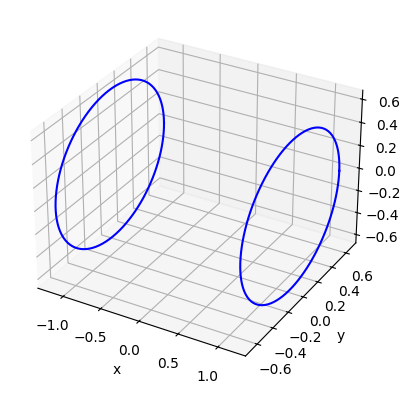

In [3]:
# Plot the coil layup, such that it is clear, which experiment setup was used. Additionally, print coil-diameter, currrent and windings, since they can not be determined by the plot alone

fig_coil_layup = plt.figure()
ax_coil_layup = fig_coil_layup.add_subplot(111, projection='3d')
for k in range(all_coils.shape[0]):
    ax_coil_layup.plot(all_coils[k, :, 0], all_coils[k, :, 1], all_coils[k, :, 2], color='blue')
ax_coil_layup.set_xlabel('x')
ax_coil_layup.set_ylabel('y')
ax_coil_layup.set_zlabel('z')


print(f'The coil diameter used in the simulation is ' + r"$d_{coil}$ =" + f' {d_coil}')
print(f'The coil current used in the simulation is ' + r"$I_{coil}$ =" + f' {current}')
print(f'The number of windings of each coil used in the simulation is ' + r"$n_{windings}$ =" + f' {n_windings}')

## Plot magnetic fields (norm)

This should give some intuition on how to access and work with the given arrays. Moreover a slight intuition for the field can be obtained (maybe)

Note, that there were 3 points in the experiment where the mapper did not record any field.
At the coordinates [array([-0.4,  0.2,  0. ]), array([-0.4, -0.2,  0. ]), array([-0.4, -0.4,  0.2])] the field is set to zero manually!


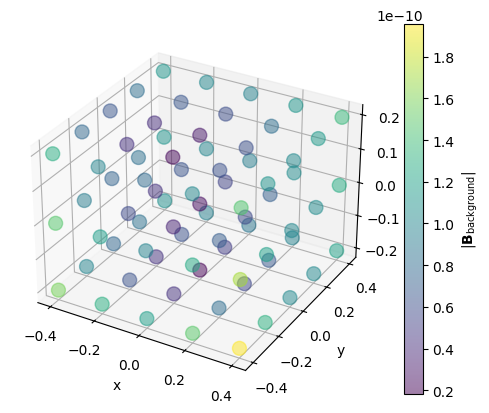

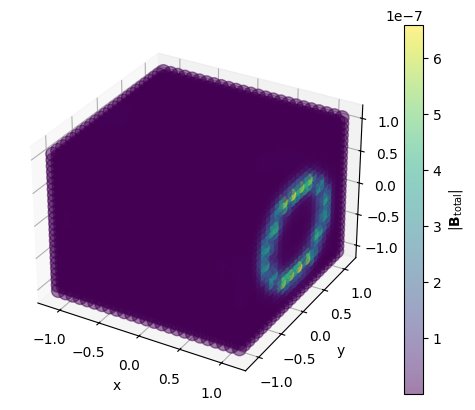

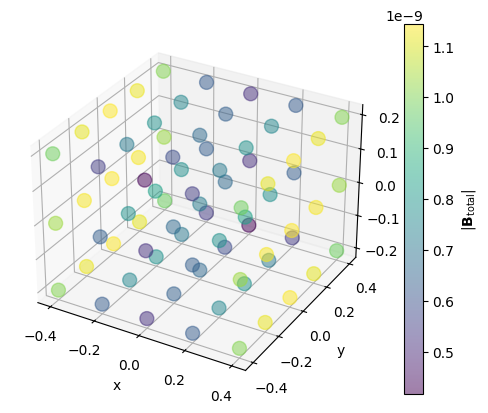

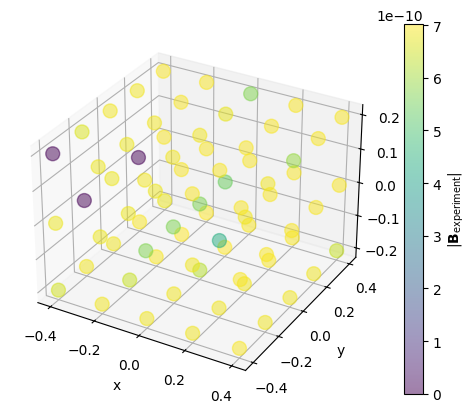

In [4]:
# Plot total field from Background (without coil currents)
fig_B_background = plt.figure()
ax_B_background = fig_B_background.add_subplot(111, projection='3d')
sc_B_background = ax_B_background.scatter(
    target_point_coord_exp[:, 0],
    target_point_coord_exp[:, 1],
    target_point_coord_exp[:, 2],
    c = np.linalg.norm(B_target_point_background, axis=1),
    s = 100,
    cmap = 'viridis',
    alpha = 0.5,
)
fig_B_background.colorbar(sc_B_background, ax=ax_B_background, label=r'$|\mathbf{B}_{\text{background}}|$')
ax_B_background.set_xlabel('x')
ax_B_background.set_ylabel('y')


# Plot total field from simulation
fig_B_tot = plt.figure()
ax_B_tot = fig_B_tot.add_subplot(111, projection='3d')
sc_B_tot = ax_B_tot.scatter(
    target_point_coord_calc[:, 0],
    target_point_coord_calc[:, 1],
    target_point_coord_calc[:, 2],
    c = np.linalg.norm(B_tot, axis=1),
    s = 100,
    cmap = 'viridis',
    alpha = 0.5,
)
fig_B_tot.colorbar(sc_B_tot, ax=ax_B_tot, label=r'$|\mathbf{B}_{\text{total}}|$')
ax_B_tot.set_xlabel('x')
ax_B_tot.set_ylabel('y')


# Plot coarsened field from simulation for better comparison
num_calc_target_points_fine = int( (len(target_point_coord_calc) + 1) **(1/3) )
coil_plane_dist_to_origin_x = 2.34/2
coil_plane_dist_to_origin_y = 2.34/2
coil_plane_dist_to_origin_z = 2.20/2
safety_distance = 0.05
B_tot_coarse = fkt.interpolate_B_on_coarse_grid(num_calc_target_points_fine, target_point_coord_exp, coil_plane_dist_to_origin_x, coil_plane_dist_to_origin_y, coil_plane_dist_to_origin_z, safety_distance, B_tot)

fig_B_tot_coarse = plt.figure()
ax_B_tot_coarse = fig_B_tot_coarse.add_subplot(111, projection='3d')
sc_B_tot_coarse = ax_B_tot_coarse.scatter(
    target_point_coord_exp[:, 0],
    target_point_coord_exp[:, 1],
    target_point_coord_exp[:, 2],
    c = np.linalg.norm(B_tot_coarse, axis=1),
    s = 100,
    cmap = 'viridis',
    alpha = 0.5,
)
fig_B_tot_coarse.colorbar(sc_B_tot_coarse, ax=ax_B_tot_coarse, label=r'$|\mathbf{B}_{\text{total}}|$')
ax_B_tot_coarse.set_xlabel('x')
ax_B_tot_coarse.set_ylabel('y')


# Plot total field from Experiment (with coil currents)
fig_B_exp = plt.figure()
ax_B_exp = fig_B_exp.add_subplot(111, projection='3d')
sc_B_exp = ax_B_exp.scatter(
    target_point_coord_exp[:, 0],
    target_point_coord_exp[:, 1],
    target_point_coord_exp[:, 2],
    c = np.linalg.norm(B_target_point_exp, axis=1),
    s = 100,
    cmap = 'viridis',
    alpha = 0.5,
)
fig_B_exp.colorbar(sc_B_exp, ax=ax_B_exp, label=r'$|\mathbf{B}_{\text{experiment}}|$')
ax_B_exp.set_xlabel('x')
ax_B_exp.set_ylabel('y')

r = []
for i in range(len(B_target_point_exp)):
    if np.all(B_target_point_exp[i]) == 0:
        r.append(target_point_coord_exp[i, :])

print(f'Note, that there were {len(r)} points in the experiment where the mapper did not record any field.\nAt the coordinates {r} the field is set to zero manually!')

## Differences of fields

Here the difference of the computed and measured field shall be shown. This should be as small as possible!

<span style="color:red">**Note** that the directions of the field until now do not have to be he same. If a ```+``` or a ```-``` is used must be evaluated manually!!!</span>

The average value of the difference in the norm of the B-field is 994 pT
The standard deviation of the difference in the norm of the B-field is 270 pT


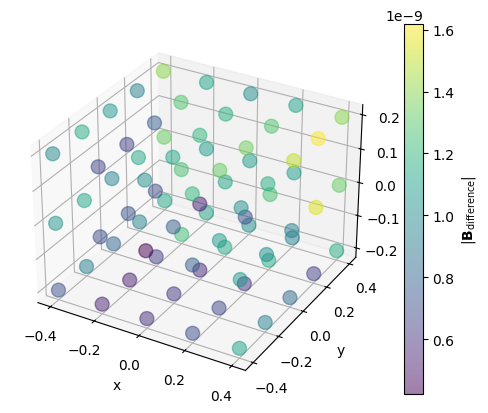

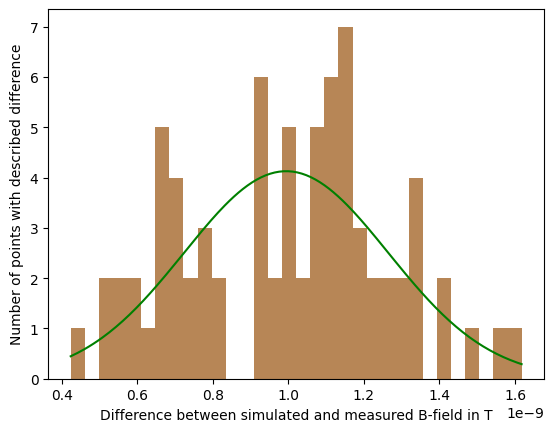

In [16]:
B_diff = np.absolute(B_tot_coarse + B_target_point_exp)
B_diff_norm = np.linalg.norm(B_diff, axis=1)

fig_B_diff = plt.figure()
ax_B_diff = fig_B_diff.add_subplot(111, projection='3d')
sc_B_diff = ax_B_diff.scatter(
    target_point_coord_exp[:, 0],
    target_point_coord_exp[:, 1],
    target_point_coord_exp[:, 2],
    c = B_diff_norm,
    s = 100,
    cmap = 'viridis',
    alpha = 0.5,
)
fig_B_diff.colorbar(sc_B_diff, ax=ax_B_diff, label=r'$|\mathbf{B}_{\text{difference}}|$')
ax_B_diff.set_xlabel('x')
ax_B_diff.set_ylabel('y')

# Calculate statistical measures
B_diff_variance = np.var(B_diff_norm)
B_diff_std = np.sqrt(B_diff_variance)
B_diff_average = np.average(B_diff_norm)

# Create Histogramm of differences
fig_B_diff_hist = plt.figure()
ax_B_diff_hist = fig_B_diff_hist.add_subplot()
ax_B_diff_hist.hist(B_diff_norm, 32, alpha = 0.8)

counts, bins, _ = ax_B_diff_hist.hist(B_diff_norm, bins=32, alpha=0.6)

x = np.linspace(min(B_diff_norm), max(B_diff_norm), 200)
bin_width = bins[1] - bins[0]
Gauss = (1 / (B_diff_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - B_diff_average) / B_diff_std) ** 2)
Gauss_scaled = Gauss * len(B_diff_norm) * bin_width

ax_B_diff_hist.plot(x, Gauss_scaled, 'g')

ax_B_diff_hist.set_xlabel('Difference between simulated and measured B-field in T')
ax_B_diff_hist.set_ylabel('Number of points with described difference')

print(f'The average value of the difference in the norm of the B-field is {B_diff_average * 10**12:.0f} pT\nThe standard deviation of the difference in the norm of the B-field is {B_diff_std * 10**12:.0f} pT')